In [1]:
# 1- importing libraries
# 2- loading and preprocessing the data 
# 3- defining the model architecture
# 4- defining the loss function and optimizer
# 5- training the model
# 6- evaluating the model
# 7- visualizing the results

In [ ]:
# =========================
# PyTorch / Deep Learning
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# =========================
# Data manipulation
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt

# =========================
# Machine Learning utilities
# =========================
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# System / device setup
# =========================
import os

cuda:0


In [ ]:
# ======================
# Device
# ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# If it prints "cuda:0", GPU is available.
# Otherwise, it is running on CPU.

Using device: cuda


In [4]:
# ======================
# Hyperparameters
# ======================
batch_size = 64
learning_rate = 1e-3
num_epochs = 30

In [5]:
# ======================
# LOADING AND PREPROCESSING THE DATA
# ======================

# Define a transformation pipeline for the MNIST dataset.
# 1. transforms.ToTensor(): Converts PIL images into PyTorch tensors (C x H x W format).
# 2. transforms.Normalize(mean, std): Standardizes the dataset using the provided mean and std.
#    - MNIST-specific values: mean=0.1307, std=0.3081 (precomputed over the dataset).
#    - This helps improve training stability and convergence speed.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load the MNIST training dataset.
# - root: Directory where the dataset will be stored.
# - train=True: Loads the training split (60,000 images).
# - transform: Applies preprocessing transformations defined above.
# - download=True: Downloads dataset if not already present locally.
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# Load the MNIST test dataset.
# - train=False: Loads the test split (10,000 images).
# - Same transformations are applied to ensure consistency between train and test data.
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

# Create an iterable DataLoader for the training dataset.
# - batch_size: Number of samples per batch (controls memory usage and training speed).
# - shuffle=True: Randomizes data order each epoch to improve generalization.
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Create a DataLoader for the test dataset.
# - shuffle=False: Keeps data order fixed for deterministic evaluation.
# - No need to shuffle test data since it is only used for model evaluation.
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [6]:
# ======================
# MODEL DEFINITION
# ======================

class Net(nn.Module):
    """
    Fully connected neural network for MNIST digit classification.
    The model takes a flattened 28x28 image (784 features) and outputs
    logits for 10 digit classes (0–9).
    """
    def __init__(self):
        super().__init__()

        # First fully connected layer: 784 → 500 neurons
        # Learns low-level feature combinations from input pixels
        self.fc1 = nn.Linear(784, 500)

        # Non-linear activation function to introduce complexity
        self.relu1 = nn.ReLU()

        # Dropout regularization to reduce overfitting (30% dropout rate)
        self.drop1 = nn.Dropout(0.3)

        # Second fully connected layer: 500 → 100 neurons
        # Learns higher-level feature representations
        self.fc2 = nn.Linear(500, 100)

        # Non-linear activation for second hidden layer
        self.relu2 = nn.ReLU()

        # Dropout applied again for regularization
        self.drop2 = nn.Dropout(0.3)

        # Output layer: 100 → 10 classes (digits 0–9)
        # Produces raw logits (not probabilities)
        self.fc3 = nn.Linear(100, 10)

    def forward(self, x):
        """
        Defines the forward pass of the network.
        """

        # Flatten input images from (batch, 1, 28, 28) → (batch, 784)
        # Required because fully connected layers expect 1D feature vectors
        x = x.view(x.size(0), -1)

        # First layer transformation + activation + dropout
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.drop1(x)

        # Second layer transformation + activation + dropout
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.drop2(x)

        # Final classification layer (logits output)
        x = self.fc3(x)

        # IMPORTANT:
        # No softmax here because CrossEntropyLoss in PyTorch
        # internally applies LogSoftmax + NLLLoss for numerical stability.
        return x


# Instantiate the model and move it to the selected device (CPU/GPU)
model = Net().to(device)

In [7]:
# ======================
# LOSS FUNCTION AND OPTIMIZER
# ======================

# Define the loss function used for multi-class classification.
# CrossEntropyLoss combines:
# - LogSoftmax (for numerical stability)
# - Negative Log Likelihood (NLL)
# It expects raw logits from the model (NO softmax applied in the model).
loss_func = nn.CrossEntropyLoss()

# Define the optimizer responsible for updating model weights.
# Adam (Adaptive Moment Estimation) is used because it:
# - Adapts learning rates for each parameter
# - Works well in practice for deep learning tasks
# - Converges faster than standard SGD in many cases
optimizer = optim.Adam(
    model.parameters(),   # parameters of the neural network to optimize
    lr=learning_rate       # step size controlling how large weight updates are
)

In [8]:
# ======================
# METRICS HISTORY STORAGE
# ======================
# These lists store loss and accuracy values for both training and testing
# across all epochs. They are useful for monitoring learning progress
# and visualizing overfitting/underfitting behavior.
loss_his_train = []
loss_his_test = []
acc_his_train = []
acc_his_test = []

# ======================
# TRAINING LOOP
# ======================
for epoch in range(num_epochs):

    # ======================
    # TRAINING PHASE
    # ======================

    # Set model to training mode
    # This enables behaviors like dropout and batch norm updates
    model.train()

    # Initialize tracking variables for training metrics
    train_loss = 0
    train_correct = 0
    total = 0

    # Iterate over mini-batches from the training dataset
    for x_batch, y_batch in train_loader:

        # Move data to the selected device (CPU or GPU)
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Reset gradients from the previous iteration
        optimizer.zero_grad()

        # Forward pass: compute model predictions
        pred = model(x_batch)

        # Compute loss between predictions and true labels
        loss = loss_func(pred, y_batch)

        # Backward pass: compute gradients
        loss.backward()

        # Update model parameters using optimizer
        optimizer.step()

        # Accumulate total training loss (scaled by batch size)
        train_loss += loss.item() * y_batch.size(0)

        # Convert logits to predicted class labels
        _, predicted = torch.max(pred, 1)

        # Count correct predictions
        train_correct += (predicted == y_batch).sum().item()

        # Update total number of samples processed
        total += y_batch.size(0)

    # Compute average training loss per sample
    train_loss /= total

    # Compute training accuracy
    train_acc = train_correct / total

    # ======================
    # EVALUATION PHASE
    # ======================

    # Set model to evaluation mode
    # Disables dropout and other training-specific behaviors
    model.eval()

    # Initialize tracking variables for test metrics
    test_loss = 0
    test_correct = 0
    total = 0

    # Disable gradient computation for faster inference and lower memory usage
    with torch.no_grad():
        for x_batch, y_batch in test_loader:

            # Move data to device
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            pred = model(x_batch)

            # Compute loss
            loss = loss_func(pred, y_batch)

            # Accumulate test loss
            test_loss += loss.item() * y_batch.size(0)

            # Get predicted class labels
            _, predicted = torch.max(pred, 1)

            # Count correct predictions
            test_correct += (predicted == y_batch).sum().item()

            # Update total sample count
            total += y_batch.size(0)

    # Compute average test loss per sample
    test_loss /= total

    # Compute test accuracy
    test_acc = test_correct / total

    # ======================
    # STORE METRICS
    # ======================
    # Save metrics for later visualization and analysis
    loss_his_train.append(train_loss)
    loss_his_test.append(test_loss)
    acc_his_train.append(train_acc)
    acc_his_test.append(test_acc)

    # Print epoch summary
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
    )

Epoch [1/30] Train Loss: 0.2861, Train Acc: 0.9127 | Test Loss: 0.1263, Test Acc: 0.9621
Epoch [2/30] Train Loss: 0.1347, Train Acc: 0.9599 | Test Loss: 0.0834, Test Acc: 0.9737
Epoch [3/30] Train Loss: 0.1076, Train Acc: 0.9673 | Test Loss: 0.0909, Test Acc: 0.9738
Epoch [4/30] Train Loss: 0.0918, Train Acc: 0.9718 | Test Loss: 0.0745, Test Acc: 0.9790
Epoch [5/30] Train Loss: 0.0821, Train Acc: 0.9748 | Test Loss: 0.0749, Test Acc: 0.9776
Epoch [6/30] Train Loss: 0.0738, Train Acc: 0.9773 | Test Loss: 0.0704, Test Acc: 0.9792
Epoch [7/30] Train Loss: 0.0675, Train Acc: 0.9790 | Test Loss: 0.0758, Test Acc: 0.9787
Epoch [8/30] Train Loss: 0.0670, Train Acc: 0.9783 | Test Loss: 0.0680, Test Acc: 0.9793
Epoch [9/30] Train Loss: 0.0585, Train Acc: 0.9817 | Test Loss: 0.0777, Test Acc: 0.9779
Epoch [10/30] Train Loss: 0.0548, Train Acc: 0.9833 | Test Loss: 0.0661, Test Acc: 0.9822
Epoch [11/30] Train Loss: 0.0545, Train Acc: 0.9826 | Test Loss: 0.0631, Test Acc: 0.9831
Epoch [12/30] Train

In [9]:
# 1- draw accuray and loss chart
# 2- claculate accuray
# 3- confusion matrix
# 3- disply some sammple image
# 8. Save/load model
# 9. Predict on new images
# 10. Grad-CAM visualization

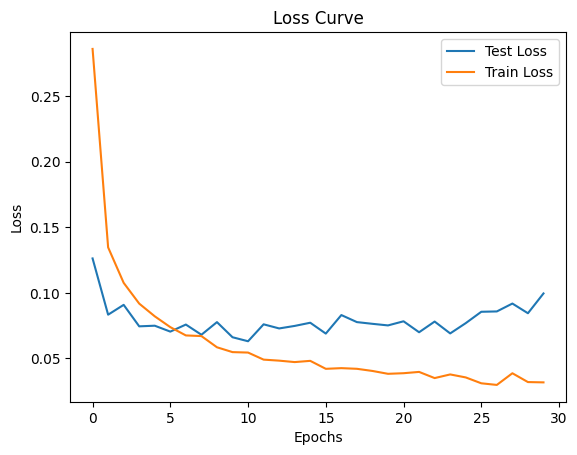

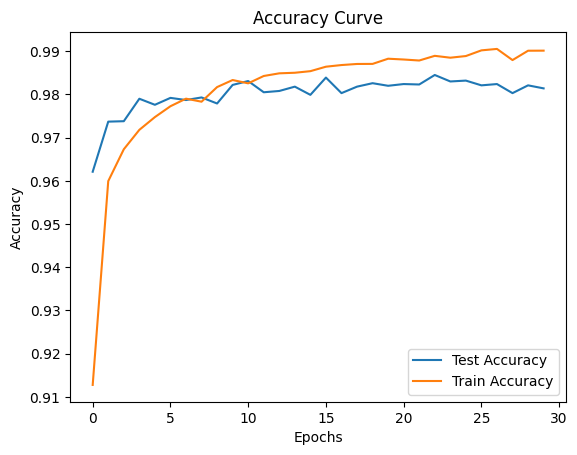

In [10]:
# ======================
# LOSS CURVE VISUALIZATION
# ======================
# Plot training and test loss over epochs to evaluate:
# - Convergence behavior
# - Potential overfitting or underfitting
# - Overall training stability

plt.plot(loss_his_test, label="Test Loss")
plt.plot(loss_his_train, label="Train Loss")

# Label the x-axis as epochs (training iterations over full dataset)
plt.xlabel("Epochs")

# Label the y-axis as loss value
plt.ylabel("Loss")

# Add a title for clarity
plt.title("Loss Curve")

# Display legend to distinguish train vs test curves
plt.legend()

# Render the plot
plt.show()


# ======================
# ACCURACY CURVE VISUALIZATION
# ======================
# Plot training and test accuracy over epochs to evaluate:
# - Model performance improvement over time
# - Generalization gap between train and test sets
# - Possible overfitting if train accuracy >> test accuracy

plt.plot(acc_his_test, label="Test Accuracy")
plt.plot(acc_his_train, label="Train Accuracy")

# Label x-axis as epochs
plt.xlabel("Epochs")

# Label y-axis as accuracy values (0 to 1)
plt.ylabel("Accuracy")

# Add descriptive title
plt.title("Accuracy Curve")

# Show legend for clarity
plt.legend()

# Display the plot
plt.show()

In [11]:
# ======================
# FINAL MODEL EVALUATION (PREDICTIONS COLLECTION)
# ======================
# This section evaluates the trained model on the test dataset
# and stores all predictions and true labels for further analysis
# such as confusion matrix, classification report, etc.

# Set model to evaluation mode
# This disables dropout and other training-specific behaviors
model.eval()

# Lists to store model outputs and ground-truth labels
all_preds = []   # predicted labels from the model
all_labels = []  # true labels from dataset

# Disable gradient computation for faster inference and lower memory usage
with torch.no_grad():
    for x_batch, y_batch in test_loader:

        # Move data to the selected device (CPU or GPU)
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass: compute raw model outputs (logits)
        outputs = model(x_batch)

        # Convert logits into predicted class labels (index of max logit)
        _, predicted = torch.max(outputs, 1)

        # Move predictions and labels to CPU and convert to NumPy arrays
        # so they can be used with sklearn metrics or visualization tools
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

In [12]:
# ======================
# CLASSIFICATION REPORT + CONFUSION MATRIX FUNCTION
# ======================
# This function evaluates a trained model on a given dataset and prints:
# 1. Classification report (precision, recall, f1-score per class)
# 2. Confusion matrix (detailed breakdown of correct/incorrect predictions)
#
# These metrics are useful for understanding model performance beyond accuracy.

def classification_report_and_confusion_matrix(model, data_loader):

    # Set model to evaluation mode
    # Disables dropout and other training-specific behaviors
    model.eval()

    # Lists to store predictions and true labels
    all_preds = []
    all_labels = []

    # Disable gradient computation for faster inference and lower memory usage
    with torch.no_grad():
        for x_batch, y_batch in data_loader:

            # Move batch data to the selected device (CPU/GPU)
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass: compute model outputs (logits)
            outputs = model(x_batch)

            # Convert logits to predicted class labels (index of highest score)
            _, predicted = torch.max(outputs, 1)

            # Move tensors to CPU and convert to NumPy for sklearn compatibility
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    # ======================
    # PERFORMANCE METRICS
    # ======================

    # Print detailed classification report:
    # - Precision: correctness of positive predictions
    # - Recall: ability to find all positive samples
    # - F1-score: harmonic mean of precision and recall
    print("Classification Report:")
    print(classification_report(all_labels, all_preds))

    # Print confusion matrix:
    # Shows how predictions are distributed across true vs predicted classes
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

In [13]:
# ======================
# MODEL EVALUATION EXECUTION
# ======================
# This section runs the previously defined evaluation function on:
# 1. Training dataset (to check how well the model learned the training data)
# 2. Test dataset (to evaluate generalization performance on unseen data)

# Evaluate model performance on the training dataset
# This helps detect overfitting if training performance is significantly higher
# than test performance.
print("Train Classification Report and Confusion Matrix")
classification_report_and_confusion_matrix(model, train_loader)

# Evaluate model performance on the test dataset
# This is the most important metric for real-world generalization ability.
print("Test Classification Report and Confusion Matrix")
classification_report_and_confusion_matrix(model, test_loader)

Train Classification Report and Confusion Matrix
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5923
           1       0.99      1.00      1.00      6742
           2       1.00      1.00      1.00      5958
           3       1.00      1.00      1.00      6131
           4       1.00      1.00      1.00      5842
           5       1.00      1.00      1.00      5421
           6       1.00      1.00      1.00      5918
           7       1.00      1.00      1.00      6265
           8       1.00      0.99      1.00      5851
           9       1.00      1.00      1.00      5949

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000

Confusion Matrix:
[[5920    1    1    0    0    0    1    0    0    0]
 [   0 6740    0    0    1    0    0    0    1    0]
 [   1    3 5949    4    0    0    0    1    

In [14]:
import random
import torch
import matplotlib.pyplot as plt

# ======================
# SAMPLE IMAGE VISUALIZATION FUNCTION
# ======================
# This function visualizes random samples from a dataset along with:
# - True labels (T)
# - Predicted labels (P)
#
# It helps in qualitative evaluation of model performance.

def display_sample_images(data_loader, num_samples=5, cols=5):

    # Set model to evaluation mode
    # Ensures dropout and other training-specific layers are disabled
    model.eval()

    # List to store all image samples with labels and predictions
    all_samples = []

    # Disable gradient computation for faster inference
    with torch.no_grad():
        for x_batch, y_batch in data_loader:

            # Move data to the selected device (CPU or GPU)
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass: get model predictions
            outputs = model(x_batch)
            _, predicted = torch.max(outputs, 1)

            # Iterate through batch and store individual samples
            for i in range(x_batch.size(0)):

                # Convert image tensor to NumPy format for visualization
                img = x_batch[i].cpu().numpy().squeeze()

                # Extract true label
                label = y_batch[i].item()

                # Extract predicted label
                pred_label = predicted[i].item()

                # Store tuple (image, true label, predicted label)
                all_samples.append((img, label, pred_label))

    # ======================
    # RANDOM SAMPLING
    # ======================
    # Randomly select a subset of samples for visualization
    samples = random.sample(all_samples, k=min(num_samples, len(all_samples)))

    # ======================
    # PLOTTING GRID SETUP
    # ======================
    # Determine number of rows needed for grid layout
    rows = (num_samples + cols - 1) // cols

    # Create figure with dynamic size based on grid
    plt.figure(figsize=(cols * 3, rows * 3))

    # ======================
    # PLOT EACH SAMPLE
    # ======================
    for idx, (img, label, pred_label) in enumerate(samples):

        # Create subplot for each image
        plt.subplot(rows, cols, idx + 1)

        # Display grayscale image
        plt.imshow(img, cmap='gray')

        # Title shows true vs predicted label
        plt.title(f"True: {label} | Pred: {pred_label}")

        # Hide axis for cleaner visualization
        plt.axis('off')

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Render the plot
    plt.show()

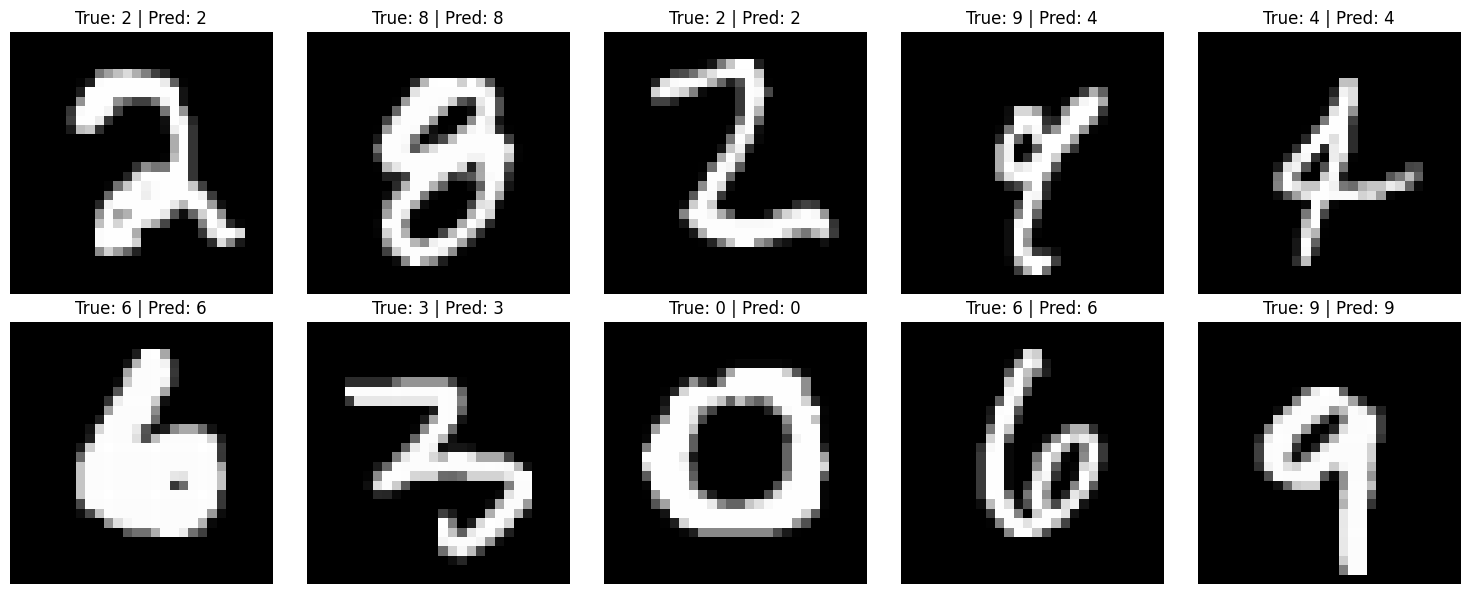

In [15]:
display_sample_images(test_loader, num_samples=10)